In [69]:
# A bank wants to understand fraud patterns in credit card transactions.
#The goal of this project is to identify high-risk transaction types and provide recommendations to reduce fraud


In [70]:
#Dataset contains: Transaction amount/merchant category / Authentification method/Device type/
# Fraud indicator (is_fraud) 0= Legitimate , 1=Fraud

In [71]:
# How many transactions are fraudulent ?


In [72]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df=pd.read_csv("/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv")

df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [74]:
conn = sqlite3.connect (':memory')

df.to_sql ('transactions',
          conn,
          index=False,
          if_exists='replace')

20000

In [75]:
query= """
SELECT COUNT (*) AS total_transactions
FROM transactions
"""

pd.read_sql(query, conn)

,total_transactions
0,20000


In [76]:
query = """
SELECT COUNT (*) AS fraud_transactions
FROM transactions
WHERE is_fraud = 1
"""

pd.read_sql (query, conn)

,fraud_transactions
0,339


In [77]:
#Fraud Rate 
query= """
SELECT
ROUND(
100.0 * SUM(is_fraud)/COUNT(*),
2
)AS fraud_rate
FROM transactions
"""

pd.read_sql(query, conn)

,fraud_rate
0,1.7


In [78]:
query= """
SELECT
merchant_category,
COUNT(*) AS transactions,
SUM (is_fraud) AS fraud_cases,
ROUND (
100.0 * SUM (is_fraud)/ COUNT (*),
2
) AS fraud_rate
FROM transactions
GROUP BY merchant_category
ORDER BY fraud_rate DESC
"""

category_result= pd.read_sql (query, conn)

category_result

,merchant_category,transactions,fraud_cases,fraud_rate
0,Crypto Exchange,561,28,4.99
1,Gift Cards,617,27,4.38
2,Gaming,1036,38,3.67
3,Electronics,2032,48,2.36
4,Streaming,1010,21,2.08
5,Utilities,1330,25,1.88
6,Healthcare,1237,16,1.29
7,Groceries,3242,40,1.23
8,Fuel,1565,19,1.21
9,Restaurants,2534,29,1.14


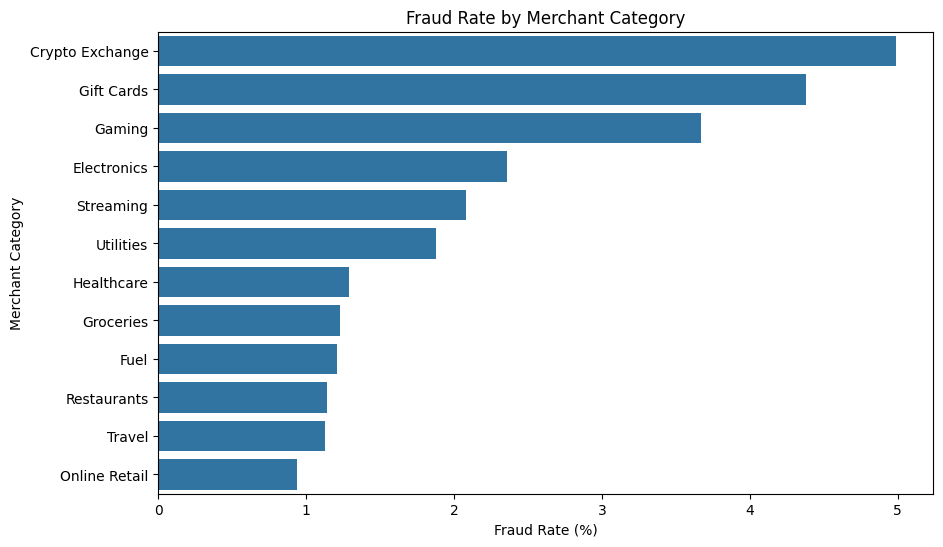

In [79]:
plt.figure (figsize=(10,6))

sns.barplot(
    data=category_result,
    x='fraud_rate',
    y= 'merchant_category'
)

plt.title ('Fraud Rate by Merchant Category')
plt.xlabel ('Fraud Rate (%)')
plt.ylabel ('Merchant Category')

plt.show()

In [80]:
query= """
SELECT
auth_method,
COUNT(*) AS transactions,
SUM (is_fraud) AS fraud_cases,
ROUND(
100.0 * SUM (is_fraud)/ COUNT (*),
2
) AS fraud_rate
FROM transactions
GROUP BY auth_method
ORDER BY fraud_rate DESC
"""

auth_result = pd.read_sql (query, conn)

auth_result

,auth_method,transactions,fraud_cases,fraud_rate
0,No Authentication,2388,106,4.44
1,OTP,4792,75,1.57
2,3D Secure,5554,86,1.55
3,PIN,4173,48,1.15
4,Biometric,3093,24,0.78


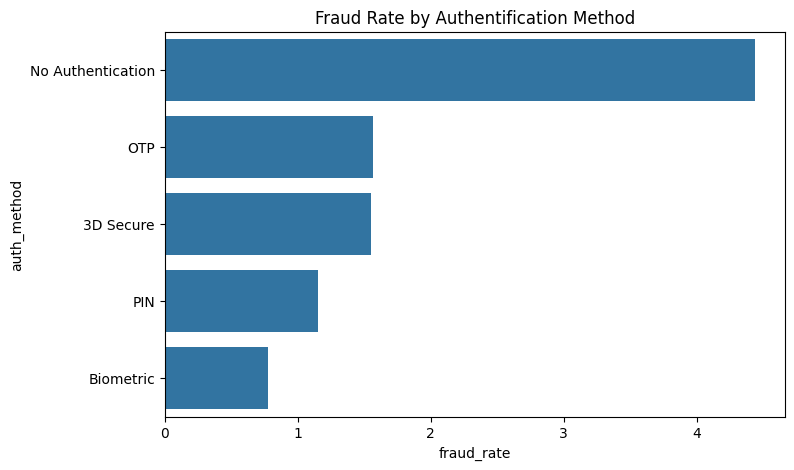

In [81]:
plt.figure(figsize=(8,5))

sns.barplot(
    data= auth_result,
    x='fraud_rate',
    y='auth_method'
)

plt.title('Fraud Rate by Authentification Method')

plt.show()

In [82]:
query= """
SELECT
channel,
COUNT(*) AS transactions,
SUM(is_fraud) AS fraud_cases,
ROUND(
100.0 * SUM (is_fraud)/COUNT(*),
2
) AS fraud_rate
FROM transactions
GROUP BY channel
ORDER BY fraud_rate DESC
"""

channel_result = pd.read_sql(query, conn)

channel_result




,channel,transactions,fraud_cases,fraud_rate
0,Online,6810,135,1.98
1,ATM,1374,25,1.82
2,In-App,3225,52,1.61
3,POS,5191,79,1.52
4,Contactless,3400,48,1.41


<function matplotlib.pyplot.show(close=None, block=None)>

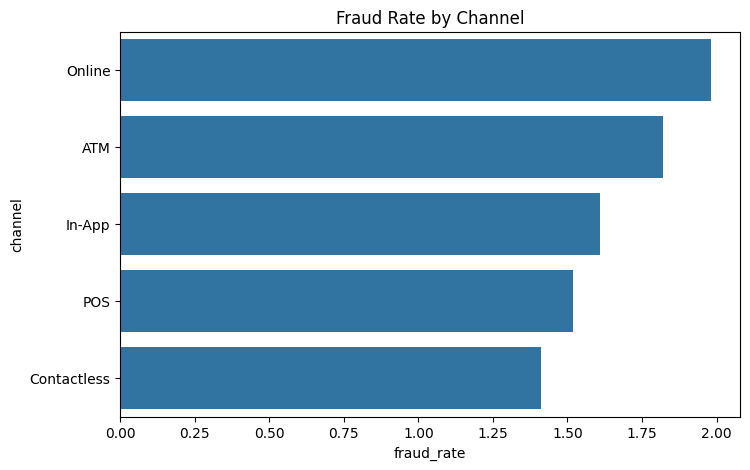

In [83]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=channel_result,
    x='fraud_rate',
    y='channel'
)

plt.title('Fraud Rate by Channel')

plt.show

In [84]:
#Foreign vs Domestic Fraud
query = """
SELECT
is_foreign_transaction,
COUNT (*) AS transactions,
SUM(is_fraud) AS fraud_cases,
ROUND(
100.0 * SUM(is_fraud)/COUNT(*),
2
) 
AS fraud_rate
FROM transactions
GROUP BY is_foreign_transaction
"""

foreign_result = pd.read_sql(query, conn)

foreign_result

,is_foreign_transaction,transactions,fraud_cases,fraud_rate
0,0,18760,266,1.42
1,1,1240,73,5.89


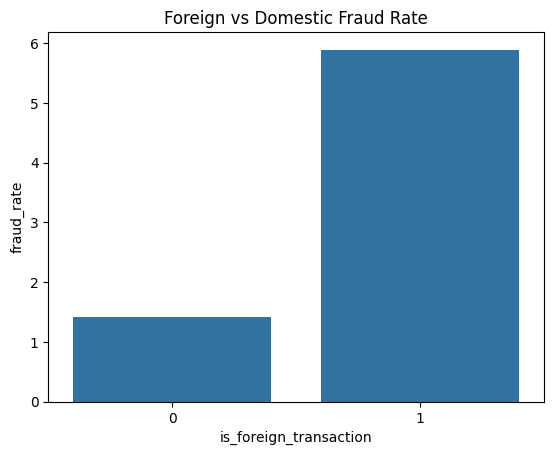

In [85]:
sns.barplot(
    data=foreign_result,
    x='is_foreign_transaction',
    y='fraud_rate'
)

plt.title('Foreign vs Domestic Fraud Rate')

plt.show ()

In [87]:
query= """
SELECT
time_of_day_hour,
SUM(is_fraud) AS fraud_cases
FROM transactions
GROUP BY time_of_day_hour
ORDER BY time_of_day_hour
"""

hour_result = pd.read_sql (query, conn)

hour_result

,time_of_day_hour,fraud_cases
0,0,13
1,1,20
2,2,28
3,3,23
4,4,20
5,5,33
6,6,8
7,7,9
8,8,9
9,9,10


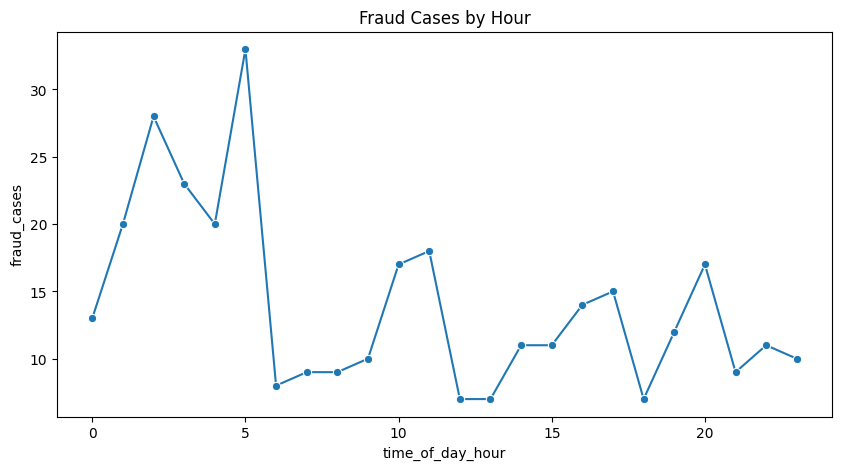

In [89]:
plt.figure (figsize=(10,5))

sns.lineplot (
    data=hour_result,
    x='time_of_day_hour',
    y='fraud_cases',
    marker='o'
)

plt.title('Fraud Cases by Hour')

plt.show ()

In [90]:
query= """
SELECT
used_vpn,
COUNT (*) AS transactions,
SUM (is_fraud) AS fraud_cases
FROM transactions
GROUP BY used_vpn
"""

pd.read_sql(query, conn)

,used_vpn,transactions,fraud_cases
0,0,18241,262
1,1,1759,77


In [91]:
query = """
SELECT
ip_country_mismatch,
COUNT(*) AS transactions,
SUM(is_fraud) AS fraud_cases
FROM transactions
GROUP BY ip_country_mismatch
"""

pd.read_sql (query, conn)

,ip_country_mismatch,transactions,fraud_cases
0,0,18834,248
1,1,1166,91


In [ ]:
#Key Findings
#Fraud Represented 2.35% of all transactions.
#Crypto Exchange merchants had the highest fraud rate.
#Foreign transactions were riskier.
#VPN usage appeared more frequently in fraud cases.

#Recommendations 
#Require stronger authentication for high-risk merchants.
#Add monitoring for foreign trasactions.
#Flag VPN usage for additional review.
#Increase fraud detection thresholds for high-risk channels.
